# Exploring Vocabulary Dynamics in Reddit Diet Communities

Online communities on platforms like Reddit offer unique insights into group dynamics, shared interests, and evolving conversations. This notebook presents an in-depth linguistic analysis of various diet-related Reddit communities, examining how their vocabulary changes over time and reflects the distinctiveness of each group's identity. By leveraging advanced computational techniques, we aim to uncover patterns of linguistic behavior that characterize dynamic and stable communities alike.

Key objectives of this analysis include:
- Measuring **specificity**: How unique or generic is the vocabulary within a community during a given period?
- Evaluating **volatility**: How consistent or variable is the usage of specific terms across time?
- Assessing **distinctiveness**: How strongly does a community's language define its identity?
- Analyzing **user retention**: How effectively do communities retain active participants between periods?

These metrics are computed by `comid.metrics.IdentityMetrics`: for each community and period, it counts
how many distinct users used each word (so a single prolific user cannot skew the vocabulary), keeps
only the top 5% most frequent words, and derives specificity, volatility, distinctiveness, dynamicity
and retention from those counts.

The corpus used for this analysis consists of top-level comments and Original Content (OC) posts from
diet-focused Reddit communities over a defined timeline, including subreddits such as `keto`, `vegan`,`whole30`, and others.

By applying methods such as word frequency analysis, specificity-volatility plots, and community metrics, this research sheds light on the linguistic patterns that differentiate dynamic communities from stable ones.

---
### Loading the Dataset
This step involves loading a dataset that encompasses all comments and Original Content (OC) from the collected Reddit diet communities.

In [ ]:
from comid import Comid

cm = Comid()
files = ['../data/diets_submissions_2023_2024.json','../data/diets_comments_2023_2024.json']
cm.load_json_files(files=files)

Loading...: 100%|██████████| 2/2 [00:19<00:00,  9.96s/it]


In [8]:
len(cm.posts)

2770373

### Filtering Relevant Data
To reduce noise in the dataset, conversation IDs are collected after removing OCs without authors or content. This ensures the data consists only of meaningful utterances.

Additionally, posts lacking authors or content are excluded, as the analysis computes vocabulary changes per author. Comments unrelated to the selected conversation IDs are filtered out.

In [9]:
cm.clean_data(remove_no_author=True,remove_no_content=True)

Filtering posts: 100%|██████████| 2770373/2770373 [00:01<00:00, 2045103.74it/s]


Number of removed posts: 1379249


An overview of the processed dataset is generated to provide insights into its structure, including counts of OCs, comments/replies, and exclusions due to missing content or authors.

In [10]:
from comid.explorer import Explorer
# Initialize the Explorer with the loaded posts
explorer = Explorer(cm.posts)
# Display a summary of the dataset
explorer.data_summary()

Processing statistics: 100%|██████████| 59694/59694 [00:06<00:00, 9211.47it/s] 


Number of posts:  1391124
Number of OCs: 59694
Number of OCs without content: 0 (0.0%)
Number of OCs without author: 0 (0.0%)
Number of comments/replies: 1331430
Number of comments/replies: without content: 0 (0.0%)
Number of comments/replies: without author: 0 (0.0%)


### Constructing the Convokit Corpus
To facilitate further analysis, the Convokit corpus is constructed. Each utterance is marked with its `depth` to enable subsequent processing of top-level comments (`depth 0`). Metadata such as `subreddit` information is included, allowing community-specific queries

In [11]:
from convokit import Utterance, Speaker, Corpus
utterances = []
speakers = {}
for oc, replies in explorer.thread_replies.items():
    if cm.posts[oc]['author_id'] not in speakers:
        speakers[cm.posts[oc]['author_id']] = Speaker(id=cm.posts[oc]['author_id'],meta={
            'author' : cm.posts[oc]['author'],
            'author_flair_text': cm.posts[oc]['author_flair_text']
        })
    utterances.append(Utterance(
        id=oc,
        speaker= speakers[cm.posts[oc]['author_id']],
        conversation_id=oc,
        timestamp= cm.posts[oc]['created'],
        text= cm.posts[oc]['full_text'],
        meta={
            'depth': -1,
            'subreddit': cm.posts[oc]['subreddit']
        }
    ))
    for reply in replies:
        if cm.posts[reply]['author_id'] not in speakers:
            speakers[cm.posts[reply]['author_id']] = Speaker(id=cm.posts[reply]['author_id'],meta={
                'author' : cm.posts[reply]['author'],
                'author_flair_text': cm.posts[reply]['author_flair_text']
            })
        utterances.append(Utterance(
            id= reply,
            speaker= speakers[cm.posts[reply]['author_id']],
            conversation_id=oc,
            reply_to= cm.posts[reply]['parent_id'],
            timestamp= cm.posts[reply]['created'],
            text= cm.posts[reply]['full_text'],
            meta={
                'depth': cm.posts[reply]['depth'],
                'subreddit': cm.posts[reply]['subreddit']
            }
        ))
corpus = Corpus(utterances = utterances)

A summary of the Convokit corpus is displayed, and memory used by intermediate variables is released

In [12]:
corpus.print_summary_stats()

#release memory
cm = None

Number of Speakers: 196054
Number of Utterances: 1391124
Number of Conversations: 59694


### Preprocessing Reddit Text for Analysis

Using the `TextCleaner` class from Convokit, we will preprocess the data to clean and identify special texts such as URLs and numbers for utterances that correspond to top-level comments.

In [13]:
from convokit import TextCleaner

text_cleaner = TextCleaner(replace_text=False,verbosity=1000, input_filter=lambda utt: utt.meta['depth'] == 0)
corpus = text_cleaner.transform(corpus)

1000/1391124 utterances processed
2000/1391124 utterances processed
3000/1391124 utterances processed
4000/1391124 utterances processed
5000/1391124 utterances processed
6000/1391124 utterances processed
7000/1391124 utterances processed
8000/1391124 utterances processed
9000/1391124 utterances processed
10000/1391124 utterances processed
11000/1391124 utterances processed
12000/1391124 utterances processed
13000/1391124 utterances processed
14000/1391124 utterances processed
15000/1391124 utterances processed
16000/1391124 utterances processed
17000/1391124 utterances processed
18000/1391124 utterances processed
19000/1391124 utterances processed
20000/1391124 utterances processed
21000/1391124 utterances processed
22000/1391124 utterances processed
23000/1391124 utterances processed
24000/1391124 utterances processed
25000/1391124 utterances processed
26000/1391124 utterances processed
27000/1391124 utterances processed
28000/1391124 utterances processed
29000/1391124 utterances proc


To clean Reddit text and prepare it for analysis, a custom `TextProcessor` will be implemented. This processor removes special marks, filters only distinct nouns, and stores the results in the `words` metadata for top-level utterances.

In [14]:
import re
from convokit import TextProcessor
import redditcleaner as rc
import contractions
import nltk

#download nltk packages
nltk.download('stopwords')
stopwords = nltk.corpus.stopwords.words('english')
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger_eng')

# custom preprocess text
def proc_text(text):
    # cleaning text
    proc = rc.clean(text) # reddit cleaner
    proc = contractions.fix(proc).lower() # contractions and lowercase

    #filtering just DISTINCT NOUNS and removing special tokens from TextCleaner
    tokens = nltk.word_tokenize(proc)
    tags = nltk.pos_tag(tokens)
    n = len(tags)
    proc = {t[0] for i, t in enumerate(tags) if (t[1] in ('NN','NNP','NNS','NNPS'))
            and not (i > 0 and i < n-1 and tags[i-1][0] == '<' and tags[i+1][0] == '>' ) }

    proc = re.sub(r'[\W\d_]+', ' ', ' '.join(proc)).split() # remove non-alphanumeric
    proc = [word  for word in proc if word not in stopwords] # remove stopwords
    proc = [word for word in proc if len(word) >= 3] # remove word less than 3 characters

    return  proc

text_processor = TextProcessor(proc_fn=proc_text,input_field="cleaned", output_field='words',verbosity=1000, input_filter=lambda utt: utt.meta['depth'] == 0)
corpus = text_processor.transform(corpus)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\thenrisa\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\thenrisa\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\thenrisa\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


1000/1391124 utterances processed
2000/1391124 utterances processed
3000/1391124 utterances processed
4000/1391124 utterances processed
5000/1391124 utterances processed
6000/1391124 utterances processed
7000/1391124 utterances processed
8000/1391124 utterances processed
9000/1391124 utterances processed
10000/1391124 utterances processed
11000/1391124 utterances processed
12000/1391124 utterances processed
13000/1391124 utterances processed
14000/1391124 utterances processed
15000/1391124 utterances processed
16000/1391124 utterances processed
17000/1391124 utterances processed
18000/1391124 utterances processed
19000/1391124 utterances processed
20000/1391124 utterances processed
21000/1391124 utterances processed
22000/1391124 utterances processed
23000/1391124 utterances processed
24000/1391124 utterances processed
25000/1391124 utterances processed
26000/1391124 utterances processed
27000/1391124 utterances processed
28000/1391124 utterances processed
29000/1391124 utterances proc

Verifying if the `words` metadata contains the expected processed information. A random utterance is selected using a try-except block to ensure that only utterances with the `words` metadata (top-level comments) are sampled.


In [15]:
fail = True
while fail:
    try:
        utt = corpus.random_utterance()
        utt.meta['words']
        fail = False
    except:
        fail = True
print(f"**id** {utt.id}\n**community: {utt.meta['subreddit']}\n**text: {utt.text}\n**words: {utt.meta['words']}")

**id** kxhdjx6
**community: Paleo
**text: Fortunately none of us asked you


Signed, person doing Paleo for 4+ years who manages to eat out and have a life.
**words: ['paleo', 'years', 'none', 'life', 'person']


### Grouping Utterances into Periods

`Comid.period_key(timestamp, period_type)` is a static method on the `Comid` class that generates a
period group key from a Unix timestamp. The supported period types include:


- **`d`**: DaysIt is used both to tag utterances below and internally by `IdentityMetrics.from_corpus`, so the two stay in agreement.

- **`w`**: Weeks

- **`f`**: Fortnight- **`y`**: Years

- **`m`**: Months- **`q`**: Quarters

In [16]:
for utt in corpus.iter_utterances():
    utt.meta['period'] = Comid.period_key(utt.timestamp,'m')

communities = sorted(list({utterance.meta["subreddit"] for utterance in corpus.iter_utterances()}))
periods = sorted(list({utterance.meta["period"] for utterance in corpus.iter_utterances()}))
print (communities)
print (periods)

['Paleo', 'carnivore', 'keto', 'mediterraneandiet', 'nutrition', 'vegan', 'veganketo', 'whole30']
['2023-01', '2023-02', '2023-03', '2023-04', '2023-05', '2023-06', '2023-07', '2023-08', '2023-09', '2023-10', '2023-11', '2023-12', '2024-01', '2024-02', '2024-03', '2024-04', '2024-05', '2024-06', '2024-07', '2024-08', '2024-09', '2024-10', '2024-11', '2024-12', '2025-01', '2025-02', '2025-03', '2025-04']


### Building the IdentityMetrics

`IdentityMetrics.from_corpus` builds, in a single pass over the corpus, all the count tables needed for
specificity, volatility, distinctiveness, dynamicity and retention:

- Lexical records (used for word counts) are the `depth == 0` utterances that have a `words` metadata field
  (`lexical_depths=(0,)`, `words_field="words"`), i.e. the top-level comments processed by `TextProcessor` above.
- Activity records (used only for retention) are *every* utterance regardless of depth (`activity_depths=None`),
  so retention reflects any kind of participation (OC, top-level comment or reply), not just top-level comments.
- `min_percentile=95` keeps, per community and period, only the top 5% most frequent words.
- `log_base=10` sets the logarithm base used by specificity/volatility (`log_base=2` is also supported).

In [17]:
from comid.metrics import IdentityMetrics

metrics = IdentityMetrics.from_corpus(
    corpus,
    group_key="subreddit",
    period_type="m",
    words_field="words",
    lexical_depths=(0,),
    activity_depths=None,
    min_percentile=95,
    log_base=10,
    speaker_dedup=True,
)

Counting words: 638317it [00:43, 14812.13it/s]
Counting activity: 1391124it [00:08, 162294.86it/s]


### Example Queries and Outputs

Query: Word Count for "vegan" in the Community "vegan" During July 2023

In [18]:
metrics.word_table('vegan', '2023-07').set_index('word').loc['vegan', 'count']

np.int64(1184)

 Query: Word Count for "calcium" Across All Periods

In [19]:
{period: int(count) for period in periods
 if (count := sum(metrics.word_table(community, period).set_index('word')['count'].get('calcium', 0)
                   for community in communities)) > 0}

{'2023-02': 104,
 '2023-03': 85,
 '2023-04': 19,
 '2023-05': 21,
 '2023-07': 67,
 '2023-08': 48,
 '2023-10': 31,
 '2023-11': 28,
 '2023-12': 59,
 '2024-01': 93,
 '2024-02': 72,
 '2024-03': 94,
 '2024-04': 84,
 '2024-05': 114,
 '2024-07': 73,
 '2024-08': 69,
 '2024-09': 58,
 '2024-10': 81,
 '2024-11': 89,
 '2024-12': 43}

### Calculating the Specificity of a Word in a Community

To measure how specific a word is within a community for a given period, we use `IdentityMetrics.specificity(word, group, period)`.
A higher specificity value indicates that the word is unique to the community, while a value closer to zero suggests
the word is more generic.

In [20]:
print(f"paleo specificity in Paleo community: {metrics.specificity('paleo','Paleo','2024-07')}")
print(f"day specificity in Paleo community: {metrics.specificity('day','Paleo','2024-07')}")

paleo specificity in Paleo community: 2.5864919903342396
day specificity in Paleo community: 0.22602480681839096


### Calculating the Volatility of a Word in a Community

`IdentityMetrics.volatility(word, group, period)` measures how consistently a word occurs across time within
a community. A higher volatility value suggests that the word frequency varies significantly over time, while
a value closer to zero indicates stable usage.

In [21]:
print(f"noodles volatility in Paleo community: {metrics.volatility('noodles', 'Paleo', '2024-07')}")
print(f"potatoes volatility in Paleo community: {metrics.volatility('potatoes', 'Paleo', '2024-07')}")

noodles volatility in Paleo community: 1.419236347531472
potatoes volatility in Paleo community: 0.12698027617499605


### Visualizing Specificity and Volatility of Community Vocabulary

To explore the interplay between specificity and volatility of a community's vocabulary during a given period, the following function plots the words used in a community by these two metrics, reading the
filtered vocabulary and its metrics directly from `IdentityMetrics.word_table`.

#### Implementation: Plotting Specificity vs. Volatility


In [22]:
import matplotlib.pyplot as plt
import numpy as np

def plot_specificity_by_volatility(community_tag, period_tag, max_labels=12):
    table = metrics.word_table(community_tag, period_tag)
    labels_all = table['word'].to_numpy()
    x = table['specificity'].to_numpy(dtype=np.float64)
    y = table['volatility'].to_numpy(dtype=np.float64)

    finite_mask = np.isfinite(x) & np.isfinite(y)
    x, y = x[finite_mask], y[finite_mask]
    labels = labels_all[finite_mask]

    x_min, x_max = -1, 3
    y_min, y_max = -0.3, 1.8
    x_span = x_max - x_min   # 4.0
    y_span = y_max - y_min   # 2.1
    edge_margin = 0.12       # fraction of axis span considered 'near the edge'

    fig, ax = plt.subplots()
    ax.scatter(x, y, alpha=0.6)

    if len(x) > 0 and max_labels > 0:
        x_mid = np.median(x)
        y_mid = np.median(y)

        quadrant_indices = {
            'high_spec_high_vol': np.where((x >= x_mid) & (y >= y_mid))[0],
            'high_spec_low_vol':  np.where((x >= x_mid) & (y <  y_mid))[0],
            'low_spec_high_vol':  np.where((x <  x_mid) & (y >= y_mid))[0],
            'low_spec_low_vol':   np.where((x <  x_mid) & (y <  y_mid))[0],
        }

        def quadrant_score(q_name, i):
            if q_name == 'high_spec_high_vol': return (x[i] - x_mid) + (y[i] - y_mid)
            if q_name == 'high_spec_low_vol':  return (x[i] - x_mid) + (y_mid - y[i])
            if q_name == 'low_spec_high_vol':  return (x_mid - x[i]) + (y[i] - y_mid)
            return (x_mid - x[i]) + (y_mid - y[i])

        n_per_quadrant = max(1, max_labels // 4)

        ranked_per_quadrant = {}
        for q_name, idxs in quadrant_indices.items():
            if len(idxs) == 0:
                ranked_per_quadrant[q_name] = []
                continue
            s = np.array([quadrant_score(q_name, i) for i in idxs])
            ranked_per_quadrant[q_name] = idxs[np.argsort(s)[::-1]][:n_per_quadrant].tolist()

        # Round-robin interleave so every quadrant contributes before any gets a 2nd slot.
        selected = []
        seen = set()
        queues = list(ranked_per_quadrant.values())
        for slot in range(n_per_quadrant):
            for q in queues:
                if slot < len(q) and q[slot] not in seen:
                    selected.append(q[slot])
                    seen.add(q[slot])

        # Fill remaining slots with globally extreme points.
        if len(selected) < max_labels:
            global_score = np.abs(x - x_mid) + np.abs(y - y_mid)
            for idx in np.argsort(global_score)[::-1]:
                if idx not in seen:
                    selected.append(idx)
                    seen.add(idx)
                if len(selected) >= max_labels:
                    break

        for idx in selected:
            xp, yp = float(x[idx]), float(y[idx])

            # Default: push outward from the median.
            dx = 8 if xp >= x_mid else -8
            dy = 8 if yp >= y_mid else -8

            # Override: if the point is near an axis boundary, push toward the interior
            # so the label is not clipped outside the plot.
            if yp - y_min < edge_margin * y_span:  # near bottom edge
                dy = 10
            elif y_max - yp < edge_margin * y_span:  # near top edge
                dy = -10
            if xp - x_min < edge_margin * x_span:  # near left edge
                dx = 10
            elif x_max - xp < edge_margin * x_span:  # near right edge
                dx = -10

            ax.annotate(
                labels[idx],
                (xp, yp),
                xytext=(dx, dy),
                textcoords='offset points',
                fontsize=8,
                ha='left' if dx > 0 else 'right',
                va='bottom' if dy > 0 else 'top',
                bbox={'boxstyle': 'round,pad=0.2', 'fc': 'white', 'alpha': 0.75, 'ec': 'none'},
                arrowprops={'arrowstyle': '-', 'color': 'gray', 'lw': 0.6, 'alpha': 0.6},
            )

    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    plt.title(community_tag + ', ' + period_tag)
    plt.xlabel('Specificity')
    plt.ylabel('Volatility')
    plt.show()

#### Example Plots
1. **Community: Paleo, Period: July 2024**  

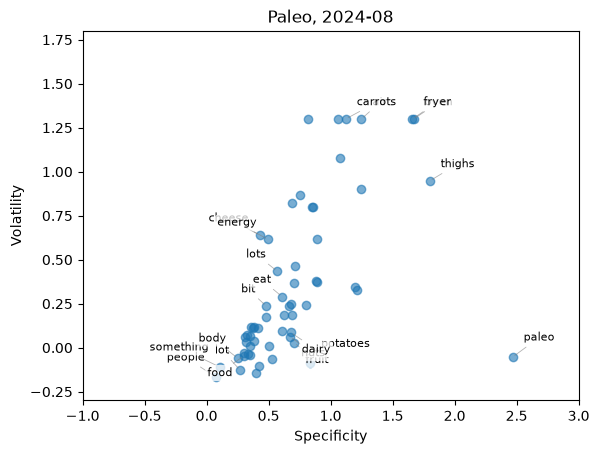

In [ ]:
plot_specificity_by_volatility('Paleo','2024-08',max_labels=20)

2. **Community: Carnivore, Period: July 2024**  

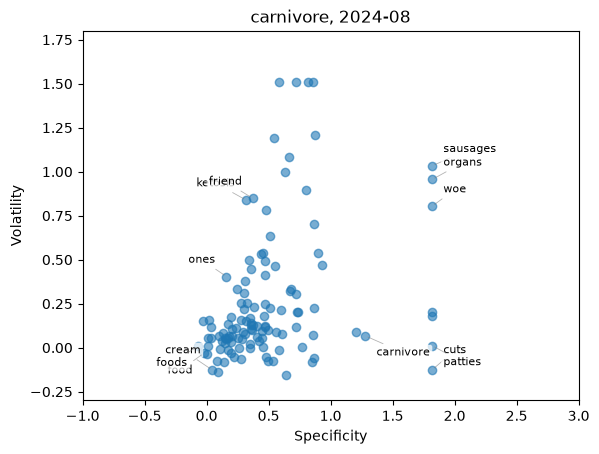

In [ ]:
plot_specificity_by_volatility('carnivore','2024-08')

3. **Community: Keto, Period: July 2024**  

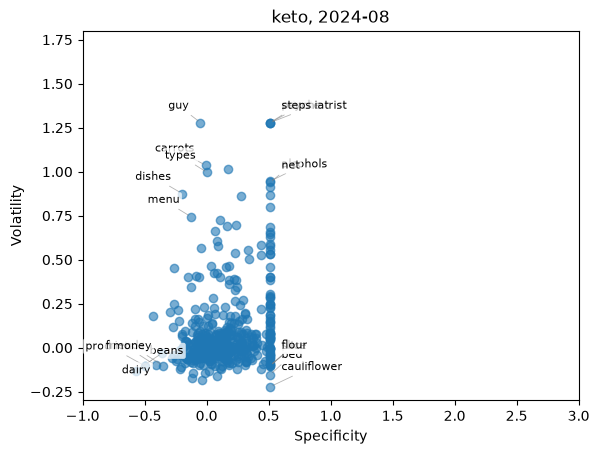

In [ ]:
plot_specificity_by_volatility('keto','2024-08',max_labels=20)

4. **Community: Mediterranean Diet, Period: July 2024**


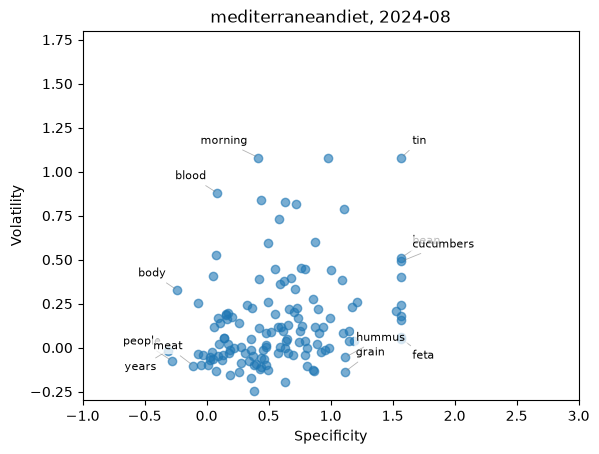

In [ ]:
plot_specificity_by_volatility('mediterraneandiet','2024-08')

5. **Community: Nutrion, Period: July 2024**  

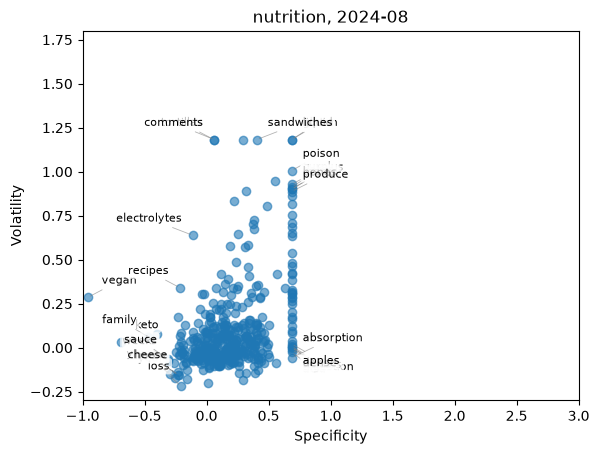

In [ ]:
plot_specificity_by_volatility('nutrition','2024-08',max_labels=30)

6. **Community: Whole30, Period: July 2024**


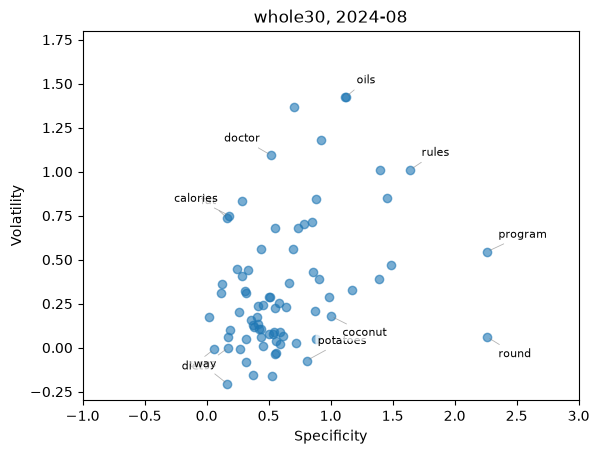

In [ ]:
plot_specificity_by_volatility('whole30','2024-08')

7. **Community: vegan, Period: July 2024**  

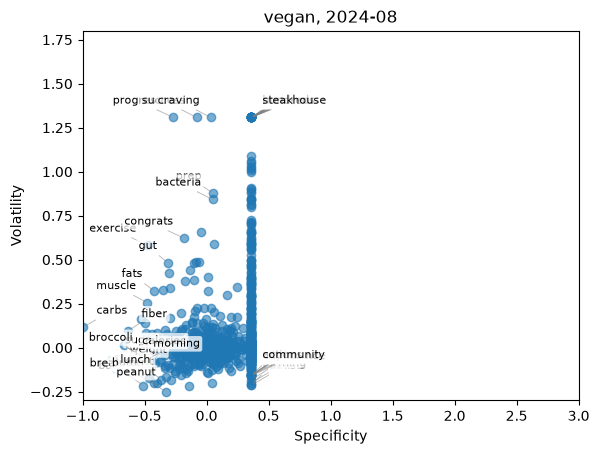

In [ ]:
plot_specificity_by_volatility('vegan','2024-08',max_labels=50)

8. **Community: Vegan Keto, Period: July 2024**


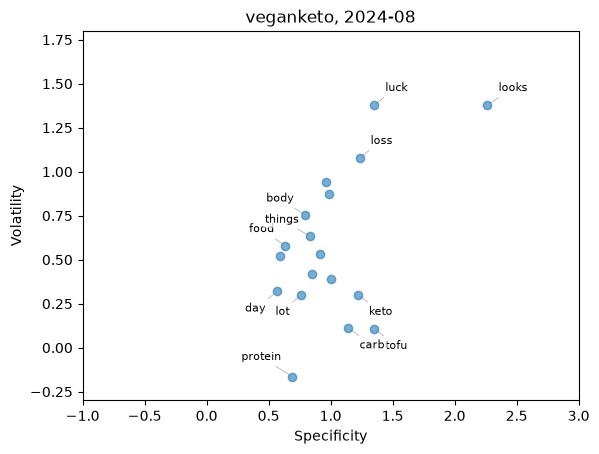

In [ ]:
plot_specificity_by_volatility('veganketo','2024-08')


### Calculating and Visualizing Community Metrics

This section defines key metrics for analyzing community vocabulary and user behavior over time. These
metrics include:

- **Distinctiveness:** `metrics.distinctiveness(community)` -- average specificity of the community's vocabulary, measuring how unique a community's language is.
- **Dynamicity:** `metrics.dynamicity(community)` -- average volatility of the community's vocabulary, measuring the consistency of language usage over time.
- **User Retention:** `metrics.retention(community)` -- average retention rate between consecutive periods, measuring how well a community retains users.

Calling each method without a `period` argument averages the metric across all periods for that community.

In [31]:
arr_distinctiveness = np.array([metrics.distinctiveness(community) for community in communities],dtype=np.float64)
for idx, community in enumerate(communities):
    print(f" {community} {arr_distinctiveness[idx]}")

 Paleo 0.7132820591591749
 carnivore 0.4587561727646609
 keto 0.1702791429382374
 mediterraneandiet 0.6530868530905636
 nutrition 0.22656171593558902
 vegan 0.13194606510394022
 veganketo 1.1937385233772975
 whole30 0.7133478247747588


In [32]:
arr_dynamicity = np.array([metrics.dynamicity(community) for community in communities],dtype=np.float64)
for idx, community in enumerate(communities):
    print(f" {community} {arr_dynamicity[idx]}")

 Paleo 0.4284084571741058
 carnivore 0.23548643363781033
 keto 0.10785216924970754
 mediterraneandiet 0.2676659378621316
 nutrition 0.14247398986687884
 vegan 0.11460775289445875
 veganketo 0.6379850077492594
 whole30 0.41437787555074895


In [33]:
arr_retention = np.zeros_like(arr_dynamicity)
for idx, community in enumerate(communities):
    arr_retention[idx] = metrics.retention(community)
    print(f" {community} {arr_retention[idx]}")

 Paleo 0.1887774088643745
 carnivore 0.24500386088999354
 keto 0.2835057229841327
 mediterraneandiet 0.2287921516968573
 nutrition 0.2085783274557128
 vegan 0.3170725461437097
 veganketo 0.1257635295974885
 whole30 0.20993142611143212


#### Visualizing Dynamicity, Distinctiveness, and Retention

To analyze all three metrics across communities, we use a scatter plot where:

- **X-Axis:** Distinctiveness
- **Y-Axis:** Dynamicity
- **Color:** User retention rate

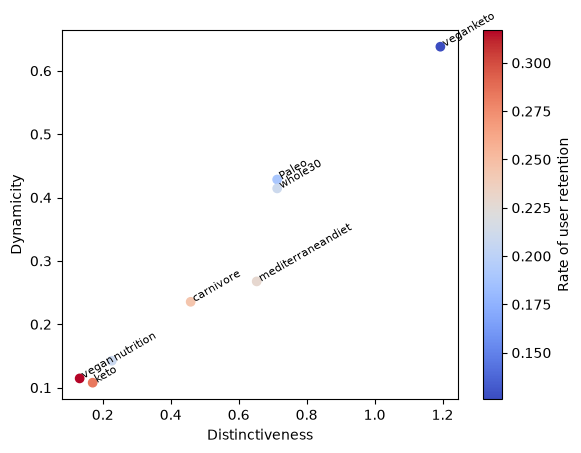

In [34]:
fig, ax = plt.subplots()
ax.scatter(arr_distinctiveness, arr_dynamicity, c=arr_retention, cmap='coolwarm')

for idx, community in enumerate(communities):
    ax.annotate(community, (arr_distinctiveness[idx], arr_dynamicity[idx]),size=8,rotation=30)
plt.xlabel("Distinctiveness")
plt.ylabel("Dynamicity")
cbar = plt.colorbar(ax.collections[0], ax=ax)
cbar.set_label("Rate of user retention")

plt.show()

### Exporting the Full Series and Summary

`IdentityMetrics.series()` gives one row per (community, period); `IdentityMetrics.summary()` gives one row
per community. `IdentityMetrics.save(folder)` writes both, plus `params.json`, so the results folder
describes itself.

In [35]:
series_df = metrics.series()
series_df

,group,period,n_lexical,n_speakers_lexical,n_active,vocab_size,distinctiveness,dynamicity,retention_next
0,Paleo,2023-01,223,171,232,62,0.627027,0.288755,0.185345
1,Paleo,2023-02,230,171,243,60,0.614122,0.295859,0.230453
2,Paleo,2023-03,225,158,235,65,0.664312,0.305413,0.157447
3,Paleo,2023-04,141,105,140,53,0.669352,0.442208,0.250000
4,Paleo,2023-05,126,96,155,58,0.793122,0.478555,0.258065
...,...,...,...,...,...,...,...,...,...
217,whole30,2024-11,204,127,168,51,0.749804,0.404255,0.148810
218,whole30,2024-12,125,91,129,44,1.126034,0.657670,0.069767
219,whole30,2025-01,22,20,38,33,0.909675,0.979420,0.026316
220,whole30,2025-02,5,5,10,3,1.586346,1.759966,0.000000


In [36]:
summary_df = metrics.summary()
summary_df

,group,n_lexical,n_speakers_lexical,n_active,n_periods,mean_vocab_size,distinctiveness,dynamicity,retention_mean,retention_sd
0,Paleo,4222,1804,2692,27,49.037037,0.713282,0.428408,0.188777,0.085382
1,carnivore,20880,6347,8836,28,123.888889,0.458756,0.235486,0.245004,0.110345
2,keto,186210,39794,52077,28,372.714286,0.170279,0.107852,0.283506,0.108986
3,mediterraneandiet,16885,5810,8140,28,88.357143,0.653087,0.267666,0.228792,0.092363
4,nutrition,113316,36139,52102,28,278.321429,0.226562,0.142474,0.208578,0.082927
5,vegan,288359,57002,78776,28,551.428571,0.131946,0.114608,0.317073,0.126707
6,veganketo,875,599,912,28,19.730769,1.193739,0.637985,0.125764,0.090742
7,whole30,7570,2449,3230,27,62.925926,0.713348,0.414378,0.209931,0.104225


In [37]:
metrics.save("results")

### Recording the Execution Environment

To make the results in the `results` folder reproducible, the machine specifications (CPU, cores, RAM,
operating system, Python version) and details of the input files (size and last modified date) are
recorded alongside `summary.csv`, `series.csv` and `params.json`, in `results/environment.txt`.


In [38]:
import os
import platform
import time


def get_total_ram_gb():
    try:
        import psutil
        return round(psutil.virtual_memory().total / (1024 ** 3), 2)
    except ImportError:
        if platform.system() == "Windows":
            import ctypes

            class MEMORYSTATUSEX(ctypes.Structure):
                _fields_ = [
                    ("dwLength", ctypes.c_ulong),
                    ("dwMemoryLoad", ctypes.c_ulong),
                    ("ullTotalPhys", ctypes.c_ulonglong),
                    ("ullAvailPhys", ctypes.c_ulonglong),
                    ("ullTotalPageFile", ctypes.c_ulonglong),
                    ("ullAvailPageFile", ctypes.c_ulonglong),
                    ("ullTotalVirtual", ctypes.c_ulonglong),
                    ("ullAvailVirtual", ctypes.c_ulonglong),
                    ("ullAvailExtendedVirtual", ctypes.c_ulonglong),
                ]

            stat = MEMORYSTATUSEX()
            stat.dwLength = ctypes.sizeof(MEMORYSTATUSEX)
            ctypes.windll.kernel32.GlobalMemoryStatusEx(ctypes.byref(stat))
            return round(stat.ullTotalPhys / (1024 ** 3), 2)
        elif platform.system() == "Linux":
            with open("/proc/meminfo") as f:
                for line in f:
                    if line.startswith("MemTotal:"):
                        return round(int(line.split()[1]) / (1024 ** 2), 2)
        return "N/A"


results_folder = "results"
os.makedirs(results_folder, exist_ok=True)

lines = [
    "ENVIRONMENT REPORT",
    "=" * 60,
    f"Generated at: {time.strftime('%Y-%m-%d %H:%M:%S')}",
    "",
    "Machine Information",
    "-" * 60,
    f"Operating System: {platform.system()} {platform.release()} ({platform.version()})",
    f"Machine: {platform.machine()}",
    f"Processor: {platform.processor()}",
    f"CPU cores (logical): {os.cpu_count()}",
    f"Total RAM (GB): {get_total_ram_gb()}",
    f"Python version: {platform.python_version()} ({platform.python_implementation()})",
    "",
    "Input Files",
    "-" * 60,
]

for file_path in files:
    lines.append(f"File: {file_path}")
    if os.path.exists(file_path):
        size_bytes = os.path.getsize(file_path)
        modified = time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(os.path.getmtime(file_path)))
        lines.append(f"  Size: {round(size_bytes / (1024 ** 2), 2)} MB ({size_bytes} bytes)")
        lines.append(f"  Last modified: {modified}")
    else:
        lines.append("  Status: NOT FOUND")
    lines.append("")

env_path = os.path.join(results_folder, "environment.txt")
with open(env_path, "w", encoding="utf-8") as out:
    out.write("\n".join(lines))

print(f"{env_path} created successfully.")


results\environment.txt created successfully.
